# Clase 07 — Árboles de decisión (CART)
## Bacán — ¿quién va a faltar a la reserva?

**Analítica de Datos · Negocios Digitales · UdeSA · Otoño 2026**

---

### El caso

**Bacán** es un bodegón de Palermo con 40 mesas y lista de espera los fines de semana. El problema es el **no-show**: uno de cada cinco que reserva no aparece, no avisa, y esa mesa queda vacía toda la noche.

El dueño no quiere pedir seña —dice que espanta clientes— pero acepta algo más suave:

> *"Todas las mañanas quiero saber cuáles de las reservas de esta noche tienen pinta de faltar. A esas las llamo yo, y si no me atienden le ofrezco la mesa a la lista de espera."*

Dos condiciones que nos puso:

1. **El modelo corre a la mañana**, así que podemos usar todo lo que ya sabemos ese día: si contestó el recordatorio de WhatsApp, el pronóstico del clima, el historial del cliente.
2. **Tiene que poder explicárselo al encargado.** Si el encargado no entiende por qué una reserva quedó marcada, no llama. Nada de cajas negras.

La condición 2 es la razón por la que hoy usamos **árboles de decisión**: un árbol es una lista de preguntas de sí o no que cualquiera puede leer y discutir.

**Los datos:** `reservas_restaurante.csv` — 2.200 reservas de los últimos meses, con el dato de si el cliente se presentó.

### Diccionario de variables

| Variable | Qué es |
|---|---|
| `id_reserva` | Identificador de la reserva |
| `dia_semana` | Día de la reserva |
| `turno` | `20:00` (primer turno) o `22:00` (segundo turno) |
| `personas` | Cantidad de cubiertos reservados |
| `dias_anticipacion` | Cuántos días antes se hizo la reserva |
| `canal` | Por dónde reservó: app, Instagram, teléfono o web |
| `reservas_previas` | Cuántas veces reservó antes en Bacán |
| `no_shows_previos` | Cuántas veces faltó antes |
| `confirmo_recordatorio` | 1 si contestó el WhatsApp de recordatorio, 0 si no |
| `prob_lluvia_pct` | Probabilidad de lluvia pronosticada para esa noche |
| `ocasion_especial` | 1 si avisó que es cumpleaños, aniversario o similar |
| `no_show` | **Target.** 1 si no se presentó, 0 si vino |

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
)

sns.set_style("whitegrid")

# Colores fijos para todo el notebook: azul = vino, rojo = faltó
AZUL, ROJO = "#1565C0", "#C62828"

---
## 2. Los datos

Cada fila es **una reserva** que ya pasó: sabemos cómo terminó. Eso es lo que le permite al modelo aprender.

In [2]:
df = pd.read_csv("reservas_restaurante.csv")

print(f"Dimensiones: {df.shape[0]} reservas x {df.shape[1]} columnas")
print(f"Nulos: {df.isna().sum().sum()}  |  Duplicados: {df.duplicated().sum()}")
df.head()

Dimensiones: 2200 reservas x 12 columnas
Nulos: 0  |  Duplicados: 0


,id_reserva,dia_semana,turno,personas,dias_anticipacion,canal,reservas_previas,no_shows_previos,confirmo_recordatorio,prob_lluvia_pct,ocasion_especial,no_show
0,R-00001,Miércoles,20:00,2,47,app,1,0,1,6,0,0
1,R-00002,Viernes,22:00,3,28,instagram,0,0,0,5,0,1
2,R-00003,Sábado,22:00,5,42,telefono,2,0,1,27,0,0
3,R-00004,Martes,20:00,1,7,web,2,0,1,29,0,0
4,R-00005,Miércoles,22:00,3,5,telefono,3,0,1,45,0,0


Sin nulos, sin duplicados, tipos correctos. **El dataset viene limpio a propósito**: hoy el foco es el modelo. En un proyecto real, la limpieza (Clase 03) te lleva más tiempo que todo el resto junto.

---
## 3. ¿Cuánta gente falta? Y la trampa que viene con eso

Antes de modelar, la pregunta más barata y la que más gente se saltea: **cómo está repartido el target**.

In [3]:
conteo = df["no_show"].value_counts()
proporcion = df["no_show"].value_counts(normalize=True).round(3)

print("Reservas por clase:")
print(conteo)
print("\nProporción:")
print(proporcion)

# El "modelo vago": predecir siempre la clase mayoritaria (nadie falta nunca)
accuracy_vago = (df["no_show"] == 0).mean()
print(f"\nAccuracy de predecir siempre 'viene': {accuracy_vago:.3f}")

Reservas por clase:
no_show
0    1745
1     455
Name: count, dtype: int64

Proporción:
no_show
0    0.793
1    0.207
Name: proportion, dtype: float64

Accuracy de predecir siempre 'viene': 0.793


**Acá está la trampa.** Un modelo que dice *"no falta nadie"* —que no mira ni una sola variable— acierta el **79% de las veces**. Si mañana llegás con un modelo de 80% de accuracy, técnicamente le ganaste al vago por un pelo, pero en la práctica no detectaste **ni una sola** de las mesas que se iban a caer.

Es exactamente la situación de Clase 06: **cuando una clase es minoritaria, el accuracy te miente**. Lo vamos a tener en cuenta todo el notebook. El número a superar es **0.793**, no cero.

---
## 4. ¿Qué distingue al que falta?

Cuatro vistas rápidas. En todas miramos lo mismo: **el porcentaje de no-show dentro de cada grupo**, comparado contra el 20,7% general.

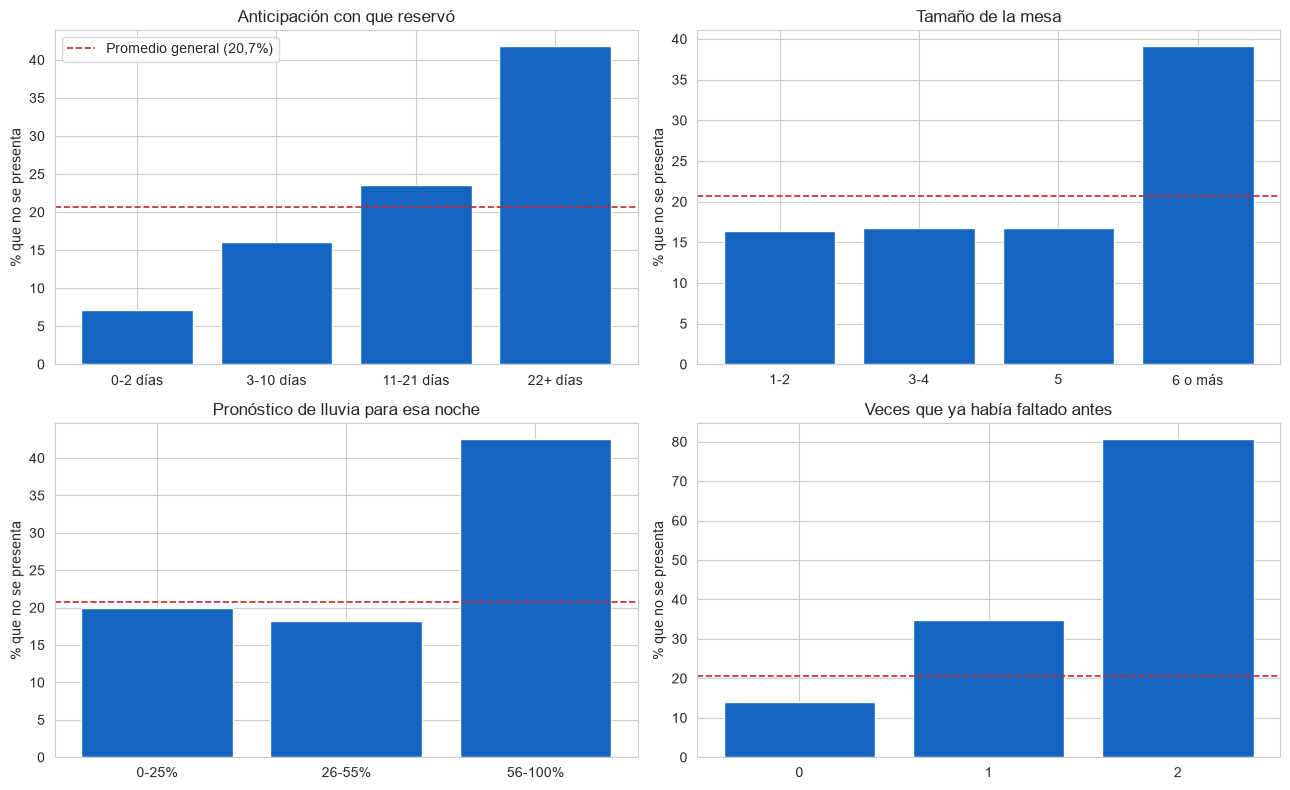

In [4]:
def tasa_por_grupo(columna, bins=None, etiquetas=None):
    """Devuelve el % de no-show por categoría (o por tramo, si paso bins)."""
    if bins is None:
        grupo = df[columna]
    else:
        grupo = pd.cut(df[columna], bins=bins, labels=etiquetas)
    return df.groupby(grupo, observed=True)["no_show"].mean() * 100


def graficar_tasa(ax, serie, titulo, leyenda=False):
    ax.bar(serie.index.astype(str), serie.values, color=AZUL, edgecolor="white")
    ax.axhline(20.7, color=ROJO, ls="--", lw=1.2, label="Promedio general (20,7%)")
    ax.set_title(titulo)
    ax.set_ylabel("% que no se presenta")
    if leyenda:
        ax.legend()


fig, axes = plt.subplots(2, 2, figsize=(13, 8))

graficar_tasa(
    axes[0, 0],
    tasa_por_grupo("dias_anticipacion", [-1, 2, 10, 21, 60],
                   ["0-2 días", "3-10 días", "11-21 días", "22+ días"]),
    "Anticipación con que reservó",
    leyenda=True,
)
graficar_tasa(
    axes[0, 1],
    tasa_por_grupo("personas", [0, 2, 4, 5, 12], ["1-2", "3-4", "5", "6 o más"]),
    "Tamaño de la mesa",
)
graficar_tasa(
    axes[1, 0],
    tasa_por_grupo("prob_lluvia_pct", [-1, 25, 55, 100], ["0-25%", "26-55%", "56-100%"]),
    "Pronóstico de lluvia para esa noche",
)
historial = tasa_por_grupo("no_shows_previos")
graficar_tasa(
    axes[1, 1],
    historial[historial.index <= 2],  # 3 y 4 no-shows previos son un puñado de casos
    "Veces que ya había faltado antes",
)

plt.tight_layout()
plt.show()

In [5]:
# El recordatorio de WhatsApp, que es lo único que el restaurante ya usaba
confirmacion = df.groupby("confirmo_recordatorio")["no_show"].agg(["mean", "size"])
confirmacion.columns = ["% no-show", "cantidad de reservas"]
confirmacion["% no-show"] = (confirmacion["% no-show"] * 100).round(1)
confirmacion.index = ["No contestó", "Contestó"]
confirmacion

,% no-show,cantidad de reservas
No contestó,52.7,495
Contestó,11.4,1705


**Qué vemos:**

- **La anticipación va al revés de lo que uno espera.** El que reserva para esta noche falta el 7%; el que reservó hace más de tres semanas, el 42%. Reservar con un mes de anticipación cuesta cero, y para cuando llega el día ya cambiaron los planes.
- **Las mesas de 6 o más faltan el doble.** Alcanza con que se caigan dos personas para que se caiga la reserva entera.
- **La lluvia no es gradual, es un escalón:** hasta 55% no pasa casi nada, arriba de 55% la tasa se duplica. Justo el tipo de relación que un árbol captura y una recta (Clase 04) no.
- **El que ya faltó, vuelve a faltar:** con un no-show previo la tasa se duplica; con dos, **8 de cada 10 vuelve a faltar**.
- **No contestar el WhatsApp es la señal más fuerte:** 53% contra 11%. Ojo con la lectura: el WhatsApp no *causa* que vengan, pero el que ya decidió no ir tampoco se toma el trabajo de contestar.

Ninguna alcanza sola. Necesitamos algo que las combine: eso es el árbol.

---
## 5. De los datos al modelo

Dos pasos: **one-hot encoding** de las columnas de texto (el árbol necesita números para cortar) y **train/test split estratificado** — `stratify=y` mantiene el 20,7% de no-shows en las dos mitades; sin eso, con una clase minoritaria, el azar puede dejarte un test con muy pocos casos y todas las métricas temblando.

**Lo que NO hacemos, y es un cambio respecto de la clase pasada:**

- **No escalamos.** KNN (Clase 05) lo necesitaba porque mide distancias: sin escalar, `prob_lluvia_pct` (0 a 100) aplastaba a `personas` (1 a 12). El árbol no mide distancias, corta una variable por vez, así que la escala le da igual.
- **No sacamos outliers.** La mesa de 12 que reservó con 55 días de anticipación **no es ruido, es justo el caso que queremos detectar**. En regresión lineal (Clase 04) un outlier te arrastra la recta; un árbol lo manda a una rama y sigue.

In [6]:
df_modelo = pd.get_dummies(df, columns=["dia_semana", "turno", "canal"], drop_first=True)

features = [c for c in df_modelo.columns if c not in ["id_reserva", "no_show"]]
X = df_modelo[features]
y = df_modelo["no_show"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} reservas  |  Test: {len(X_test)} reservas")
print(f"% no-show en train: {y_train.mean():.3f}  |  en test: {y_test.mean():.3f}")

Train: 1540 reservas  |  Test: 660 reservas
% no-show en train: 0.207  |  en test: 0.206


---
## 6. El árbol

Arrancamos con un árbol **deliberadamente chico**: `max_depth=3` (tres preguntas como máximo) y `min_samples_leaf=40` (ninguna regla puede apoyarse en menos de 40 reservas).

¿Por qué chico si podríamos dejarlo crecer? Por la condición 2 del dueño: tiene que poder leerlo. Un árbol de 200 hojas es tan caja negra como cualquier otra cosa. Además, un árbol grande memoriza: eso lo vemos en la sección 7.

In [7]:
arbol = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=40,
    random_state=42,
)
arbol.fit(X_train, y_train)

print(f"Accuracy train: {arbol.score(X_train, y_train):.3f}")
print(f"Accuracy test:  {arbol.score(X_test, y_test):.3f}")
print(f"Accuracy del modelo vago (siempre 'viene'): {1 - y_test.mean():.3f}")

Accuracy train: 0.838
Accuracy test:  0.835
Accuracy del modelo vago (siempre 'viene'): 0.794


**Cómo se lee cada caja del gráfico de abajo:**

- **Línea 1 — la regla.** Si la reserva **cumple**, va a la **izquierda**; si no, a la derecha.
- **`gini` — qué tan mezclado está el nodo.** 0 = todos de la misma clase; 0,5 = mitad y mitad. El árbol elige en cada paso la pregunta que más baja el gini de los hijos, y eso es *todo* lo que hace CART. La cuenta está en el PDF teórico.
- **`samples`:** cuántas reservas cayeron ahí. **`value`:** cómo se reparten, `[vinieron, faltaron]`. **`class`:** qué predice si fuera hoja.

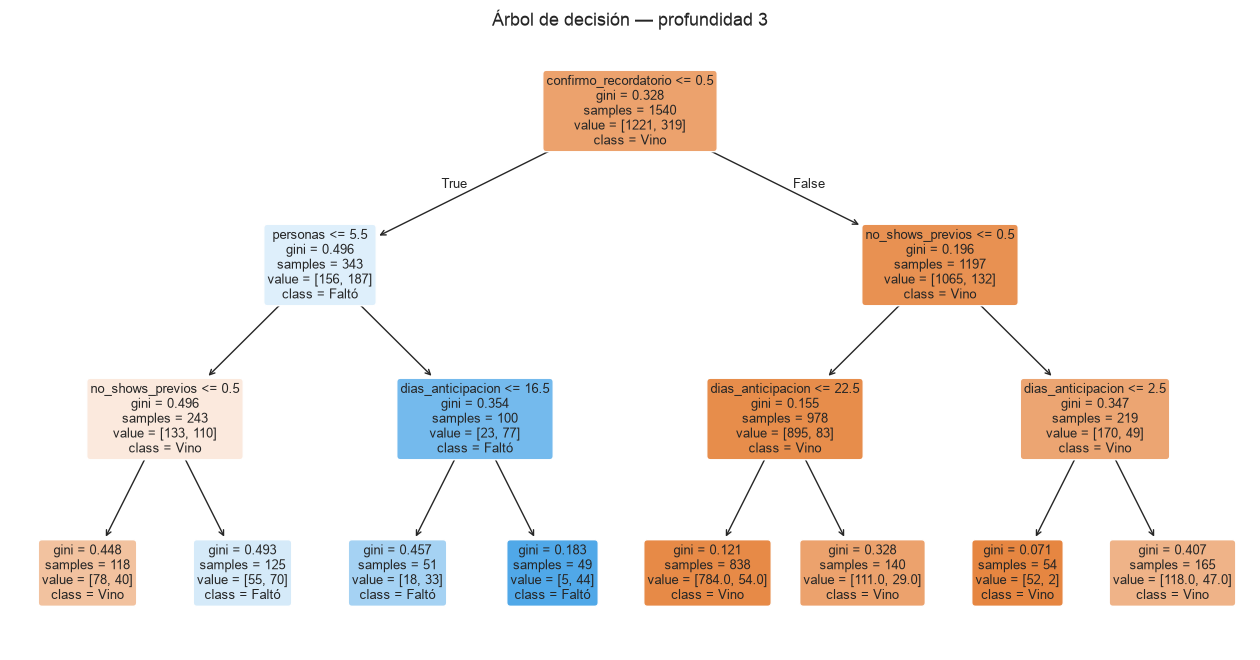

In [8]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    arbol,
    feature_names=features,
    class_names=["Vino", "Faltó"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Árbol de decisión — profundidad 3", fontsize=13)
plt.show()

**Las reglas, traducidas al idioma del encargado:**

- **La primera pregunta es si contestó el WhatsApp.** No se lo dijimos nosotros: la eligió porque es la que más baja el gini.
- **Rama izquierda (no contestó):** ahí está el riesgo. Adentro separa por **tamaño de mesa**, y después por **historial** (las mesas chicas) o por **anticipación** (las de 6 o más). La hoja más crítica del árbol: mesa grande, no contestó, reservó con más de 16 días. Ahí falta el **90%**.
- **Rama derecha (contestó):** ninguna hoja llega a mayoría de no-shows.
- **Mirá el `value`, no solo el `class`.** Dos hojas dicen las dos "Vino": la de `[784, 54]` tiene 7% de riesgo y la de `[78, 40]`, 34%. **Cinco veces más riesgo, misma etiqueta.** Esa diferencia es la que vamos a usar en la sección 9 para decidir a quién llamar.

El árbol le gana al vago (0,835 contra 0,794), pero todavía no sabemos **a costa de qué**. Eso es la sección 8.

---
## 7. ¿Y si lo dejamos crecer?

Pregunta obvia del alumno: si tres preguntas dan 83,5%, **¿por qué no diez?** Un árbol sin límites puede seguir cortando hasta que cada hoja tenga una sola reserva y acertarle al 100% del pasado.

Probémoslo: entrenamos un árbol por cada profundidad de 1 a 16, sin ningún otro límite, y miramos accuracy **en train y en test**.

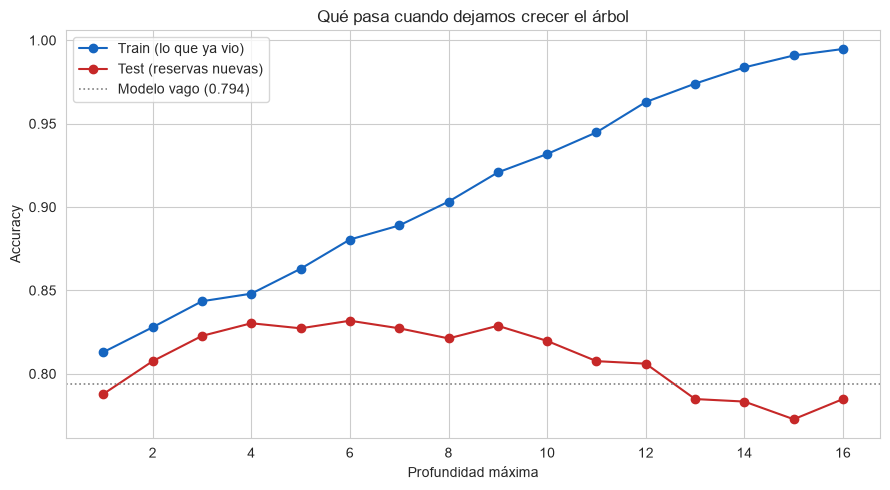

In [9]:
profundidades = range(1, 17)
acc_train, acc_test = [], []

for d in profundidades:
    modelo_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    modelo_d.fit(X_train, y_train)
    acc_train.append(modelo_d.score(X_train, y_train))
    acc_test.append(modelo_d.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(profundidades, acc_train, marker="o", color=AZUL, label="Train (lo que ya vio)")
ax.plot(profundidades, acc_test, marker="o", color=ROJO, label="Test (reservas nuevas)")
ax.axhline(1 - y_test.mean(), color="grey", ls=":", lw=1.2,
           label=f"Modelo vago ({1 - y_test.mean():.3f})")
ax.set_title("Qué pasa cuando dejamos crecer el árbol")
ax.set_xlabel("Profundidad máxima")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

**Este gráfico es el corazón de la clase.**

- En **train** la azul sube y sube: con profundidad 16 le acierta al **99%** de lo que ya vio. Se lo aprendió de memoria, reserva por reserva.
- En **test** sube hasta profundidad 4, se queda en una meseta hasta la 6 y después **baja**. Con más de 12 niveles queda **por debajo del modelo vago**: tanto trabajo para terminar peor que no hacer nada.
- Ese hueco entre las dos líneas tiene nombre: **overfitting**. El árbol profundo confundió el ruido de estas 1.540 reservas con reglas del negocio — algo tipo *"las mesas de 5 que reservaron un martes por Instagram faltan siempre"*, sostenido por tres casos. El martes que viene esa regla no sirve.

**Podar** es sacrificar aciertos sobre el pasado para no romperse con lo nuevo: `max_depth` (cuántas preguntas) y `min_samples_leaf` (casos mínimos por hoja).

Ojo con leer el gráfico como si hubiera un ganador claro: entre 4 y 6 hay una **meseta** (0,830 · 0,827 · 0,832) y esas diferencias son ruido del test. Nos quedamos con **profundidad 5 y mínimo 30 reservas por hoja**: el medio de la meseta, y el mínimo por hoja —que ningún árbol del barrido tiene— nos lleva a 0,835.

In [10]:
modelo = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=30,
    random_state=42,
)
modelo.fit(X_train, y_train)

print(f"Hojas: {modelo.get_n_leaves()}")
print(f"Accuracy train: {modelo.score(X_train, y_train):.3f}")
print(f"Accuracy test:  {modelo.score(X_test, y_test):.3f}")

Hojas: 19
Accuracy train: 0.844
Accuracy test:  0.835


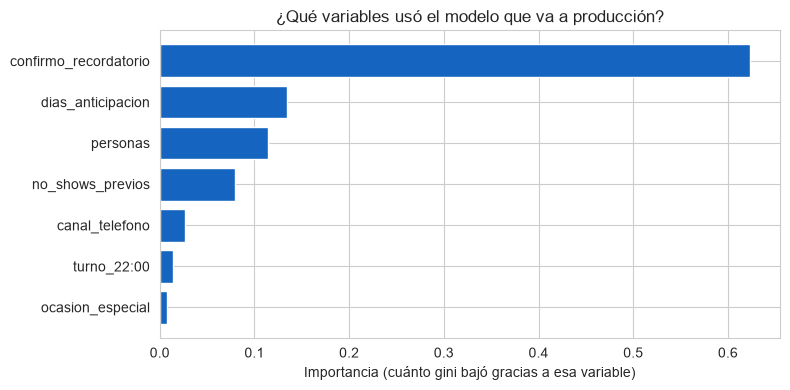

In [11]:
importancias = pd.Series(modelo.feature_importances_, index=features)
importancias = importancias[importancias > 0].sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importancias.index, importancias.values, color=AZUL)
ax.set_title("¿Qué variables usó el modelo que va a producción?")
ax.set_xlabel("Importancia (cuánto gini bajó gracias a esa variable)")
plt.tight_layout()
plt.show()

**Tres lecturas, y las tres son trampas habituales:**

- **Importa el orden, no el valor exacto.** Manda el recordatorio (0,62), después la anticipación (0,14) y el tamaño de la mesa (0,11). Son las tres preguntas que el encargado debería hacerse aunque el modelo se caiga.
- **La importancia no es causalidad ni es un R².** Que `confirmo_recordatorio` valga 0,62 **no** significa que persiguiendo a la gente para que conteste se arregle el 62% del problema. Mide cuánto la usó el árbol para separar, nada más.
- **¿Y la lluvia, que en la sección 4 era la señal más linda?** Importancia **cero**. Dos razones que valen para cualquier proyecto: lo que dice la lluvia **ya lo dijo el WhatsApp** (con mal pronóstico la gente confirma menos, 79% contra 56%), y las noches de lluvia fuerte son pocas para un mínimo de 30 por hoja. **Una variable puede ser predictiva y no entrar al árbol** — no la borres del dataset por eso.

**Una honestidad:** el modelo final tiene 19 hojas y por eso no lo dibujamos. Ahí perdimos parte de lo que el dueño había pedido. Lo que conserva es la auditoría caso por caso: `export_text(modelo, feature_names=features)` devuelve las reglas en texto. Ese es el trade-off de podar menos: cada nivel compra test y paga legibilidad.

---
## 8. El accuracy nos está mintiendo

83,5% contra el 79,3% del vago. Cuatro puntos. **¿Eso es bueno?** La respuesta no está en el accuracy: está en **cómo se reparten los errores**. Para eso, la matriz de confusión.

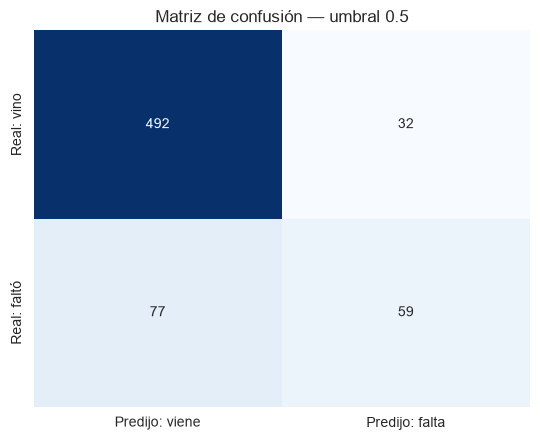

              precision    recall  f1-score   support

    Vino (0)       0.86      0.94      0.90       524
   Faltó (1)       0.65      0.43      0.52       136

    accuracy                           0.83       660
   macro avg       0.76      0.69      0.71       660
weighted avg       0.82      0.83      0.82       660



In [12]:
y_pred = modelo.predict(X_test)
matriz = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    matriz, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
    xticklabels=["Predijo: viene", "Predijo: falta"],
    yticklabels=["Real: vino", "Real: faltó"],
)
ax.set_title("Matriz de confusión — umbral 0.5")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["Vino (0)", "Faltó (1)"]))

**Los cuatro cuadrantes, en Bacán:**

| | Qué pasó | Qué cuesta |
|---|---|---|
| **TP** (59) | La marcamos y faltó | Llamamos, liberamos la mesa: **la salvamos** |
| **FP** (32) | La marcamos y vino | Llamada innecesaria. Molestia, y si soltamos la mesa, un problema |
| **FN** (77) | No la marcamos y faltó | **Mesa vacía un sábado.** El error caro |
| **TN** (492) | No la marcamos y vino | Todo bien, nadie se enteró |

**Y acá está el problema de verdad:**

- **Recall = 0,43.** De las 136 reservas que se cayeron, detectamos 59: **se escapan 77 mesas vacías.**
- **Precision = 0,65.** De las 91 que marcamos, 59 faltaron: dos de cada tres llamadas sirven.

El dueño no pregunta por el accuracy: pregunta **cuántas mesas le salvaste**, y esa es la fila del recall. ¿Y si el modelo fuera más desconfiado? Porque ese 0,5 que separa "viene" de "falta" no nos lo dio el negocio: **viene de fábrica**.

---
## 9. El umbral: la perilla que nadie mira

El árbol no devuelve "viene" o "falta". Devuelve **una probabilidad** por reserva —el porcentaje de no-shows de la hoja donde cayó— y recién después alguien la compara contra 0,5.

Ese 0,5 es una convención, no una ley. Podemos moverlo.

In [13]:
probabilidades = modelo.predict_proba(X_test)[:, 1]

muestra = pd.DataFrame({
    "personas": X_test["personas"].values,
    "dias_anticipacion": X_test["dias_anticipacion"].values,
    "confirmo_recordatorio": X_test["confirmo_recordatorio"].values,
    "prob_no_show": probabilidades.round(3),
    "realidad": np.where(y_test.values == 1, "faltó", "vino"),
}).sort_values("prob_no_show", ascending=False)

# Las que quedan del lado de adentro de la raya de fábrica, pero raspando
banda = muestra[(muestra["prob_no_show"] >= 0.30) & (muestra["prob_no_show"] < 0.50)]
faltaron = (banda["realidad"] == "faltó").sum()
print(f"Reservas con riesgo entre 30% y 50%: {len(banda)} — de esas faltaron {faltaron}")

print("\nLas 5 reservas más riesgosas de esta noche:")
muestra.head(5)

Reservas con riesgo entre 30% y 50%: 117 — de esas faltaron 34

Las 5 reservas más riesgosas de esta noche:


,personas,dias_anticipacion,confirmo_recordatorio,prob_no_show,realidad
411,6,34,0,0.898,vino
595,8,33,0,0.898,faltó
427,8,21,0,0.898,vino
410,6,60,0,0.898,faltó
440,6,23,0,0.898,faltó


**La pregunta que siempre sale:** las cinco reservas de arriba tienen **la misma probabilidad** (0,898) y **dos vinieron igual**. ¿Falló el modelo? No: esa probabilidad no es de la persona, es **de la hoja**. Las cinco cayeron en el mismo nodo del árbol, donde históricamente faltaron 9 de cada 10. El modelo nunca dice "esta persona falta", dice "en este grupo falta el 90%". Por eso hay 19 probabilidades posibles y no 660.

**Y ahí está el problema del 0,5:** hay **117 reservas con riesgo entre 30% y 50%** y con el umbral de fábrica no llamamos a ninguna, porque para el modelo "vienen". De esas 117, **se cayeron 34**. Una mesa con 39% de riesgo un sábado a la noche es una mesa que cualquier encargado llamaría sin pensarlo.

Bajar el umbral es exactamente eso: **volver al modelo más desconfiado**.

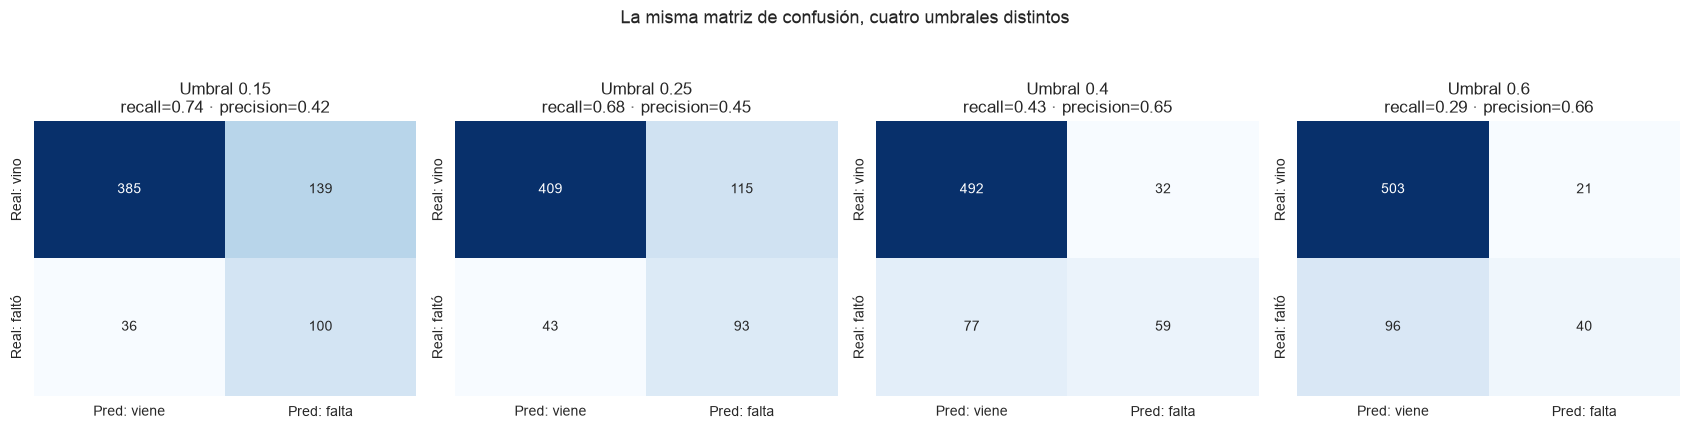

In [14]:
umbrales = [0.15, 0.25, 0.40, 0.60]

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, u in zip(axes, umbrales):
    pred_u = (probabilidades >= u).astype(int)
    cm = confusion_matrix(y_test, pred_u)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Pred: viene", "Pred: falta"],
        yticklabels=["Real: vino", "Real: faltó"],
    )
    recall_u = recall_score(y_test, pred_u)
    precision_u = precision_score(y_test, pred_u)
    ax.set_title(f"Umbral {u}\nrecall={recall_u:.2f} · precision={precision_u:.2f}")

plt.suptitle("La misma matriz de confusión, cuatro umbrales distintos", y=1.06, fontsize=13)
plt.tight_layout()
plt.show()

**Mirá cómo se mueve la plata de un cuadrante al otro.** El modelo es el mismo —no lo reentrenamos ni una vez—, lo único que cambió es dónde pusimos la raya:

- **Umbral 0,15:** recall 0,74 (salvamos 3 de cada 4 mesas) pero precision 0,42 (más de la mitad de las llamadas son a gente que venía igual).
- **Umbral 0,60:** precision 0,66, pero recall 0,29: se nos caen 96 mesas.
- **El panel de 0,40 es idéntico a la matriz de la sección 8**, que estaba en 0,50. No es un error de copiado: ninguna hoja tiene probabilidad entre 0,39 y 0,51, así que ahí adentro mover el umbral no cambia **ni una sola** predicción.

**Precision y recall se mueven siempre en direcciones opuestas.** No existe el umbral que mejore las dos: elegís **de qué lado querés equivocarte**, y eso lo decide el negocio, no el data scientist.

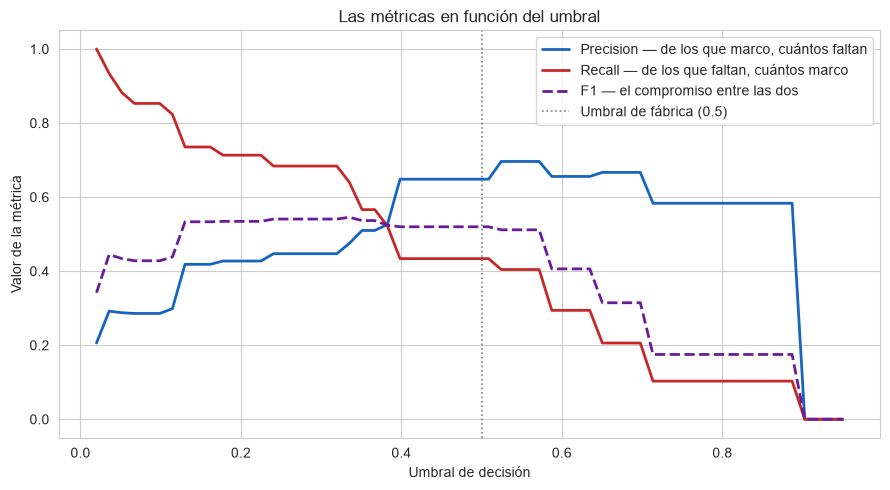

In [15]:
grilla = np.linspace(0.02, 0.95, 60)
precisiones, recalls, f1s = [], [], []

for u in grilla:
    pred_u = (probabilidades >= u).astype(int)
    precisiones.append(precision_score(y_test, pred_u, zero_division=0))
    recalls.append(recall_score(y_test, pred_u))
    f1s.append(f1_score(y_test, pred_u))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grilla, precisiones, color=AZUL, lw=2, label="Precision — de los que marco, cuántos faltan")
ax.plot(grilla, recalls, color=ROJO, lw=2, label="Recall — de los que faltan, cuántos marco")
ax.plot(grilla, f1s, color="#6A1B9A", lw=2, ls="--", label="F1 — el compromiso entre las dos")
ax.axvline(0.5, color="grey", ls=":", lw=1.2, label="Umbral de fábrica (0.5)")
ax.set_title("Las métricas en función del umbral")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Valor de la métrica")
ax.legend()
plt.tight_layout()
plt.show()

**Cómo se lee este gráfico:**

- Las curvas **se cruzan cerca de 0,38**; el máximo de **F1** —el promedio armónico de precision y recall— cae un poco antes, entre 0,25 y 0,35. F1 es la métrica a mirar cuando no tenés una razón fuerte para priorizar una sobre la otra.
- **El umbral de fábrica queda a la derecha de ese máximo.** El default nos deja del lado conservador, marcando poco. Para este problema, donde la mesa vacía es el error caro, es el lado equivocado.
- Son **escalones**, no rampas: el árbol tiene 19 hojas, así que solo puede devolver 19 probabilidades distintas. De 0,4 a 0,5 las tres métricas ni se mueven.

**Un atajo que conviene conocer:** `class_weight="balanced"` logra algo parecido desde adentro del modelo, haciendo que cada no-show del train pese casi cuatro veces más que una reserva que sí vino.

---
## 10. Curva ROC: todos los umbrales de un saque

Cada umbral nos da un par (recall, falsas alarmas). La **curva ROC** los dibuja todos juntos, para no tener que elegir de antemano:

- Eje Y: **TPR** = recall = de los que faltan, a cuántos marco.
- Eje X: **FPR** = de los que sí venían, a cuántos molesto al pedo.

Moverse por la curva **es** mover el umbral. Y el **AUC** (el área debajo) resume la curva entera en un número: la probabilidad de que el modelo le asigne más riesgo a una reserva que se cayó que a una que no. 0,5 es tirar una moneda; 1,0 es adivinar perfecto.

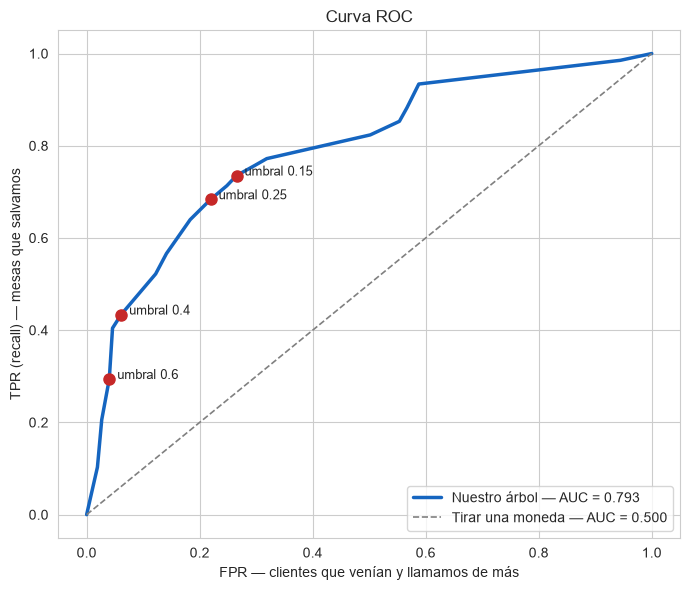

In [16]:
fpr, tpr, cortes = roc_curve(y_test, probabilidades)
auc = roc_auc_score(y_test, probabilidades)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=AZUL, lw=2.5, label=f"Nuestro árbol — AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], ls="--", color="grey", lw=1.2, label="Tirar una moneda — AUC = 0.500")

# Marcamos sobre la curva los cuatro umbrales que probamos arriba
for u in umbrales:
    pred_u = (probabilidades >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_u).ravel()
    ax.plot(fp / (fp + tn), tp / (tp + fn), "o", color=ROJO, markersize=8)
    ax.annotate(f"  umbral {u}", (fp / (fp + tn), tp / (tp + fn)), fontsize=9)

ax.set_xlabel("FPR — clientes que venían y llamamos de más")
ax.set_ylabel("TPR (recall) — mesas que salvamos")
ax.set_title("Curva ROC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Lectura:**

- **AUC = 0,79.** Lejos de la diagonal: si agarrás una reserva que se cayó y una que no, le da más riesgo a la correcta 8 de cada 10 veces. Para un árbol de 19 hojas, es un resultado honesto.
- **Los cuatro puntos rojos son los umbrales de la sección 9.** Subir por la curva = bajar el umbral = salvar más mesas molestando a más gente. No hay forma de subir sin ir a la derecha: es el trade-off, dibujado.
- **No es una curva suave, son tramos rectos.** Con 19 hojas hay 19 puntos posibles y nada en el medio — fijate el tramo largo del final, donde ya no queda ningún corte disponible. Una logística, que da una probabilidad distinta por cliente, dibuja una curva redondeada.
- **El AUC compara modelos, no elige umbrales.** Para decidir a quién llamamos esta noche falta un dato más: cuánto cuesta cada error.

---
## 11. La decisión: de las métricas a la plata

Le preguntamos al dueño cuánto le cuesta cada error:

- **Mesa vacía (FN):** una mesa promedio son casi 4 cubiertos y deja unos **$38.000 de margen**. Si nadie se sienta, ese margen no existe.
- **Llamada innecesaria (FP):** la llamada no cuesta casi nada, pero ocupa al encargado y algún cliente se ofende con el "¿confirmás?" y no vuelve. Puesto en plata, unos **$9.000**.

Un FN cuesta **más de cuatro veces** lo que un FP. Con esos dos números dejamos de discutir métricas y buscamos el umbral que minimiza el costo. Son estimaciones del dueño, no verdades reveladas.

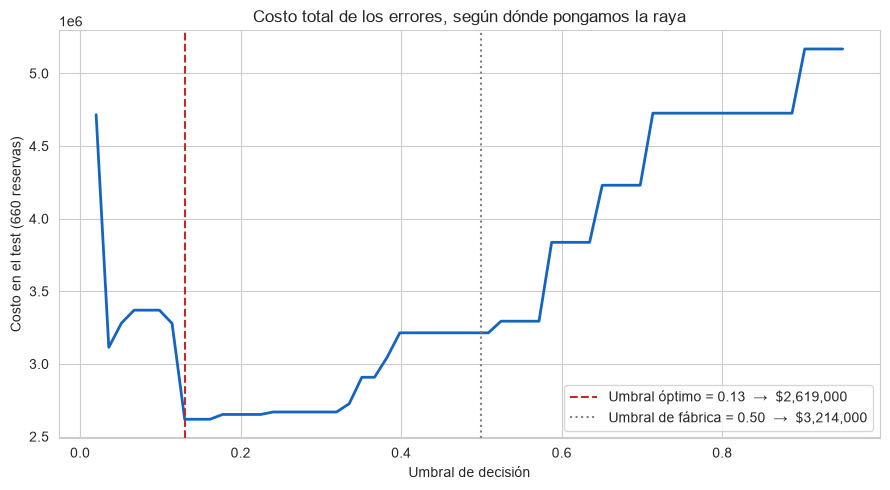

No hacer nada (hoy):        $5,168,000
Llamar a todo el mundo:     $4,716,000
Modelo con umbral 0.50:     $3,214,000
Modelo con umbral 0.13:     $2,619,000


In [17]:
COSTO_FP = 9_000     # llamar a alguien que sí venía
COSTO_FN = 38_000    # mesa vacía

costos = []
for u in grilla:
    pred_u = (probabilidades >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_u).ravel()
    costos.append(fp * COSTO_FP + fn * COSTO_FN)

costos = np.array(costos)
umbral_optimo = grilla[int(np.argmin(costos))]
costo_optimo = costos.min()

# Los dos escenarios sin modelo, para tener contra qué comparar
costo_sin_modelo = int(y_test.sum()) * COSTO_FN            # no llamamos a nadie
costo_llamar_todos = int((y_test == 0).sum()) * COSTO_FP   # llamamos a todos

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grilla, costos, color=AZUL, lw=2)
ax.axvline(umbral_optimo, color=ROJO, ls="--", lw=1.5,
           label=f"Umbral óptimo = {umbral_optimo:.2f}  →  ${costo_optimo:,.0f}")
ax.axvline(0.5, color="grey", ls=":", lw=1.5,
           label=f"Umbral de fábrica = 0.50  →  ${costos[np.argmin(np.abs(grilla - 0.5))]:,.0f}")
ax.set_title("Costo total de los errores, según dónde pongamos la raya")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Costo en el test (660 reservas)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"No hacer nada (hoy):        ${costo_sin_modelo:,.0f}")
print(f"Llamar a todo el mundo:     ${costo_llamar_todos:,.0f}")
print(f"Modelo con umbral 0.50:     ${costos[np.argmin(np.abs(grilla - 0.5))]:,.0f}")
print(f"Modelo con umbral {umbral_optimo:.2f}:     ${costo_optimo:,.0f}")

**Este cuadro es el que se lleva el dueño:**

- **Las dos estrategias sin modelo son las peores.** No llamar a nadie: $5,2 millones en mesas vacías. Llamar a todos: $4,7 millones en clientes molestos. Hay que elegir *a quién*.
- **Con el umbral de fábrica el modelo ya ahorra** ($3,2 millones), pero se queda a mitad de camino. **Moviendo la raya a 0,13 baja otro 18%**, hasta $2,6 millones, sin tocar el modelo ni una vez. Esa mejora no vino de un algoritmo más moderno: vino de mirar la matriz de confusión con los precios del negocio al lado.
- **El fondo de la curva es plano entre 0,13 y 0,32**, así que no hace falta clavar el número exacto: moverse a 0,25 cuesta $50.000 más. Y el óptimo es una propiedad **del negocio**: si mañana Bacán cobra seña, se corre solo.
- **Ojo:** ese óptimo lo elegimos mirando el test. Ajustarlo muy fino es sobreajustar el umbral a estas 660 reservas — la trampa de la sección 7 con otro disfraz.

---
## 12. Qué le decimos al dueño

Sin nombrar un solo algoritmo:

> *"De cada 10 mesas que se te caen, podemos avisarte de 7 a la mañana. Para eso vas a llamar a unas 4 de cada 10 reservas de la noche, y algo más de la mitad de esas llamadas van a ser a gente que venía igual: es el precio de no perderte las otras. Sobre los últimos meses te hubiera ahorrado casi la mitad de lo que perdiste en mesas vacías. Las tres señales que más pesan son si contestan el recordatorio, con cuánta anticipación reservaron y el tamaño de la mesa."*

**Para llevarse:**

1. **Un árbol es una lista de preguntas**, y cada una se elige bajando el gini. Su fortaleza no es la precisión: es que se puede leer, discutir y auditar.
2. **Cuanto más profundo, más memoriza.** Podar cambia aciertos sobre el pasado por estabilidad sobre lo que viene.
3. **El accuracy engaña** cuando una clase es minoritaria. Precision y recall cuentan la historia real.
4. **El 0,5 no es sagrado:** es una decisión de negocio disfrazada de default, y acá moverlo valió más que cambiar de modelo.

**La próxima clase:** entrená este mismo árbol con otro `random_state` y van a cambiar las reglas. Esa inestabilidad es la debilidad de CART, y la solución es una de las mejores ideas del machine learning: entrenar cientos de árboles y hacerlos votar. Eso es **Random Forest**.

---
## Para ver en casa

1. **La perilla de adentro.** Reentrená con `class_weight="balanced"` y comparalo con el actual **al mismo umbral 0,5**. ¿Se parece a haber bajado el umbral? ¿Cuál preferís y por qué?
2. **Otros precios.** Si Bacán cobra una seña de $15.000, la mesa vacía pasa a costar $23.000 en vez de $38.000. Recalculá el umbral óptimo: ¿para qué lado se movió? ¿Tiene sentido?
3. **La inestabilidad de CART.** Entrená el árbol de la sección 6 con `random_state=1`, `2` y `3`. ¿Cambia la primera pregunta? Esa es la debilidad que Random Forest viene a resolver.